In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df_earthquake = pd.read_csv('/Users/veron/Desktop/natural disasters project/notebooks/earthquake_scaled.csv')
df_earthquake_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/notebooks/cleaned_earthquake.csv')
df_flood_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_flood.csv')
df_storm_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_storm.csv')
df_wildfire_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_wildfire.csv')

In [3]:
df_earthquake.head()

,Unnamed: 0,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted,Continent
0,0,1.0,4.464151,0.000000,3.083815,6.544791,Asia
1,1,1.0,0.000000,-0.100821,-0.015572,2.719934,Americas
2,2,1.0,0.657448,0.795922,-0.018685,4.507823,Americas
3,3,-1.0,0.588407,-0.819079,1.409201,6.544791,Asia
4,4,2.0,1.347560,1.667560,0.003167,7.282288,Americas


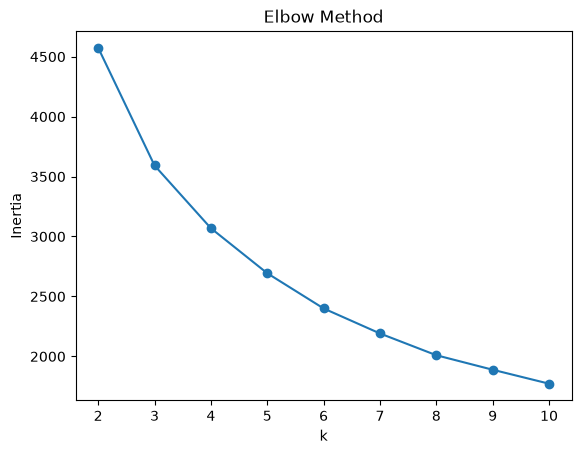

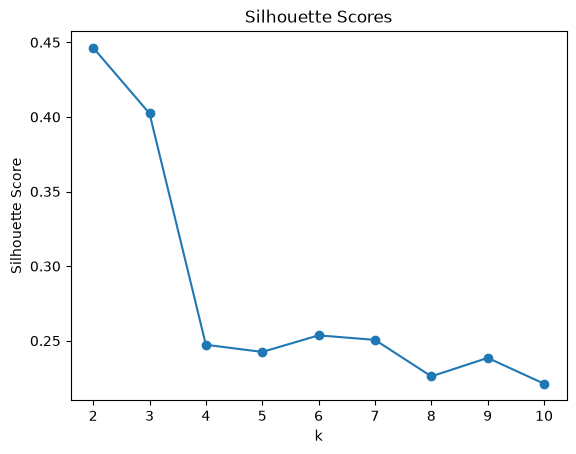

In [4]:
earthquake_features = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'Damages Adjusted']
X = df_earthquake[earthquake_features]

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Elbow plot
plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette plot
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

### It appears k = 2-3 is the best k value.

### First try k = 2.

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_earthquake['cluster'] = kmeans.fit_predict(df_earthquake[earthquake_features])

df_earthquake.groupby('cluster')[earthquake_features].mean()


,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
cluster,,,,,
0,0.893023,2.048833,0.436470,1.140035,2.273013
1,0.129568,-0.163978,-0.115668,-0.019872,0.013769


### Next, try k = 3.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_earthquake['cluster'] = kmeans.fit_predict(df_earthquake[earthquake_features])

df_earthquake.groupby('cluster')[earthquake_features].mean()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
cluster,,,,,
0,1.147239,2.381343,0.780859,1.064851,0.393263
1,0.537037,1.017198,-0.041369,0.843191,4.075504
2,0.075561,-0.242727,-0.157520,-0.044241,-0.003690


In [7]:
df_earthquake['cluster'].value_counts()

cluster
2    847
0    163
1    108
Name: count, dtype: int64

In [15]:
df_earthquake_unscaled['cluster'] = df_earthquake['cluster']

df_earthquake_unscaled.groupby('cluster')[['Dis Mag Value', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)"]].median()

,Dis Mag Value,Total Deaths,Total Affected,Total Damages ('000 US$)
cluster,,,,
0,7.0,250.0,92725.0,384800.0
1,7.0,31.0,3935.0,55600.0
2,6.0,4.0,2531.0,29000.0


In [9]:
df_earthquake_unscaled.groupby('cluster')['Year'].mean()


cluster
0    1999.595092
1    1975.583333
2    2001.271547
Name: Year, dtype: float64

In [14]:
df_earthquake_unscaled["Total Damages ('000 US$)"].describe()

count    4.760000e+02
mean     1.741405e+06
std      1.173739e+07
min      2.000000e+00
25%      5.000000e+03
50%      5.500000e+04
75%      3.772000e+05
max      2.100000e+08
Name: Total Damages ('000 US$), dtype: float64

### Note:
- Total Damages ('000 US$) shows extreme right-skew (std >> mean); raw cluster means are outlier-distorted, so log-transformed (scaled) rankings and/or raw medians are used for interpretation instead.

## Grouping (Unscaled)
- Cluster 0: Highest deaths, highest damages
- Cluster 1: Moderate deaths, lower damages
- Cluster 2: Baseline
==> This reveals why using CPI is important when calculating the adjusted damages. Even though cluster 1 consists of earthquakes that occured significantly earlier than clusters 0 and 2, and so the unscaled damages are greater, CPI allows us to see that the earthquakes' impact is still comparable to later years, if not greater. 
## Grouping (Scaled):
- Cluster 0: Highest deaths, high damages
- Cluster 1: Moderate deaths, moderate damages
- Cluster 2: Baseline

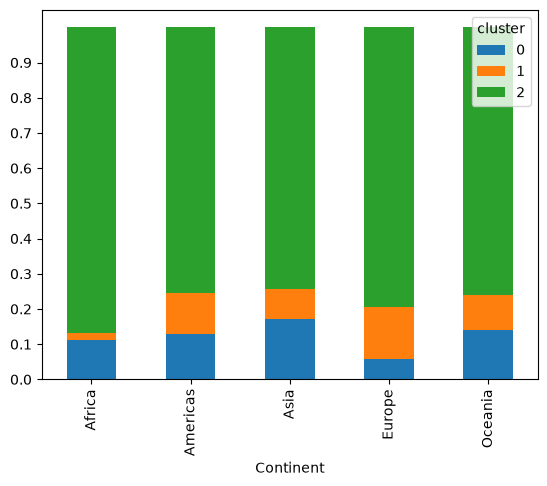

In [ ]:
y_ticks = np.arange(0, 1, 0.1)

pd.crosstab(df_earthquake['Continent'], df_earthquake['cluster'], normalize='index').plot(kind='bar', stacked=True).set_yticks(y_ticks)
# For cluster 0, it appears asia is significantly higher, and europe is significantly lower
# cluster 1, africa is very small, yet its cluster 0 still on par with americas and oceania, whose cluster 1 is a lot bigger. europe's is the largest here, makes sense as cluster 0 is the smallest for europe
# cluster 2 (doesn't really matter)

# so, asia has the most deadly earthquakes (makes sense)
# africa has the littlest damages despite having on par deadly earthquakes
# europe's earthquakes not as deadly, but highest damages 

- Asia — highest human toll: ~18% of Asian earthquakes fall in the high-fatality cluster, the highest of any continent.
- Africa — fatal but not costly: comparable fatality rates to the Americas and Oceania (~11% vs ~13-14%), but by far the lowest share of high-damage events (~2%) — likely reflecting lower economic/infrastructure value at risk relative to population exposure.
- Europe — costly but not fatal: the lowest fatality share (~6%) but the highest damage share (~15%), consistent with a wealthier region where earthquake risk translates more into economic loss than loss of life.